In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl

# Problem 1
### 1.1

In [2]:
sals = pd.read_csv("data/salamanders.csv", delimiter=";", index_col="SITE")
X = sals.PCTCOVER.to_numpy()
y = sals.SALAMAN.to_numpy()

In [3]:
poreg = skl.linear_model.PoissonRegressor()

In [4]:
model = poreg.fit(X.reshape(-1, 1),
                  y)
print(model.coef_[0], model.intercept_)

0.032365258337728 -1.4782989265850834


In [5]:
sample = model.predict(np.linspace(0, 100, 200).reshape(-1, 1))

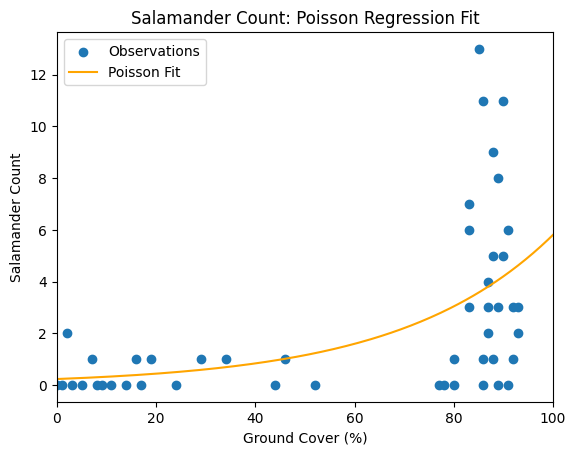

In [6]:
plt.scatter(X, y, label="Observations")
plt.plot(np.linspace(0, 100, 200), sample, "orange", label="Poisson Fit")
plt.xlim(0, 100)
plt.xlabel("Ground Cover (%)")
plt.ylabel("Salamander Count")
plt.title("Salamander Count: Poisson Regression Fit")
plt.legend(loc="upper left")
plt.savefig("images/fig1.png", bbox_inches="tight")

In [7]:
print(f"Intercept from fit: {model.intercept_:5.5f}")
print(f"Coefficient from fit: {model.coef_[0]:5.5f}")

Intercept from fit: -1.47830
Coefficient from fit: 0.03237


### 1.2

In [8]:
n_data = len(X)
n_samples = 1000
rng = np.random.default_rng()
bootstrap = rng.poisson(np.exp(model.intercept_+(model.coef_[0]*X)), (n_samples, n_data))

In [9]:
bootints = []
bootcoefs = []
for bootsample in bootstrap:
    bootreg = skl.linear_model.PoissonRegressor()
    bootmodel = bootreg.fit(X.reshape(-1, 1),
                           bootsample)
    bootints.append(bootmodel.intercept_)
    bootcoefs.append(bootmodel.coef_[0])

bootints = np.array(bootints)
bootcoefs = np.array(bootcoefs)

In [10]:
def ci(stat, bootstats):
    fifth = (2*stat) - np.percentile(bootstats, 95)
    ninetyfifth = (2*stat) - np.percentile(bootstats, 5)
    return (fifth, ninetyfifth)

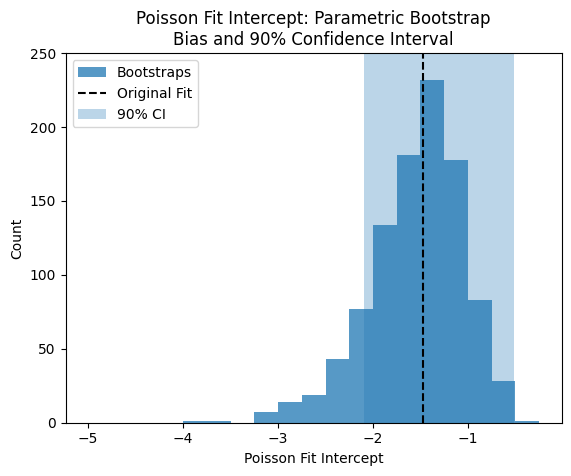

In [11]:
plt.hist(bootints, alpha=0.75, label="Bootstraps", bins=np.arange(-5,0,0.25))
plt.vlines(model.intercept_, 0, 300, "k", linestyles="--", label="Original Fit")
xmin, xmax = ci(model.intercept_, bootints)
plt.axvspan(xmin=xmin, xmax=xmax, ymax=300, alpha=0.3, label="90% CI")
plt.xlabel("Poisson Fit Intercept")
plt.ylabel("Count")
plt.legend()
plt.ylim(0, 250)
plt.title("Poisson Fit Intercept: Parametric Bootstrap\nBias and 90% Confidence Interval")
plt.savefig("images/fig3.png")

In [12]:
intbias = model.intercept_ - bootints.mean()
print(f"Bias for Intercept: {intbias:5.5f}")
print(f"90% CI for Intercept: ({xmin:5.5f}, {xmax:5.5f})")

Bias for Intercept: 0.06958
90% CI for Intercept: (-2.09752, -0.51453)


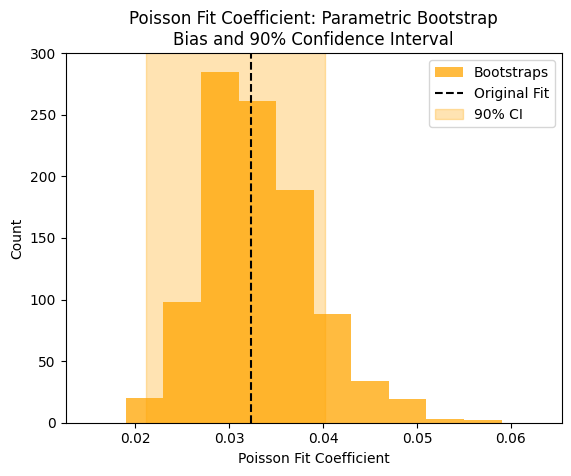

In [13]:
plt.hist(bootcoefs, alpha=0.75, label="Bootstraps", color="orange", bins=np.arange(0.015, 0.065, 0.004))
plt.vlines(model.coef_[0], 0, 300, "k", linestyles="--", label="Original Fit")
xmin, xmax = ci(model.coef_[0], bootcoefs)
plt.axvspan(xmin=xmin, xmax=xmax, ymax=300, alpha=0.3, label="90% CI", color="orange")
plt.xlabel("Poisson Fit Coefficient")
plt.ylabel("Count")
plt.legend(loc="upper right")
plt.ylim(0, 300)
plt.title("Poisson Fit Coefficient: Parametric Bootstrap\nBias and 90% Confidence Interval")
plt.savefig("images/fig2.png")

In [14]:
coefbias = model.coef_[0] - bootcoefs.mean()
print(f"Bias for Coefficient: {coefbias:5.5f}")
print(f"90% CI for Coefficient: ({xmin:5.5f}, {xmax:5.5f})")

Bias for Coefficient: -0.00075
90% CI for Coefficient: (0.02120, 0.04019)


# Problem 2
### 2.1

In [15]:
surge = pd.read_csv("data/norfolk-hourly-surge-2015.csv")
surge["Datetime"] = pd.to_datetime(surge.Date + " " + surge["Time"])
surge["Weather"] = surge["Verified"] - surge["Predicted"]

Text(0.5, 1.0, 'Norfolk Surge Data for 2015: Predicted vs. Observed')

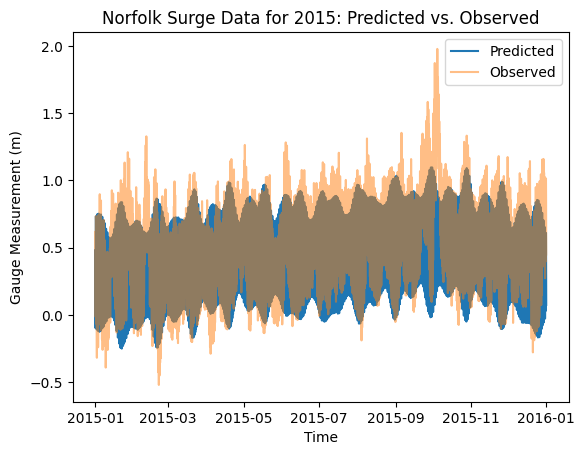

In [16]:
plt.plot(surge.Datetime, surge.Predicted, label="Predicted")
plt.plot(surge.Datetime, surge.Verified, label="Observed", alpha=0.5)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Gauge Measurement (m)")
plt.title("Norfolk Surge Data for 2015: Predicted vs. Observed")

/var/folders/r2/zyspwvbn6298j0cwr7cnqmh80000gn/T/ipykernel_25401/2581320630.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Norfolk Surge Data for 2015: Observed - Predicted')

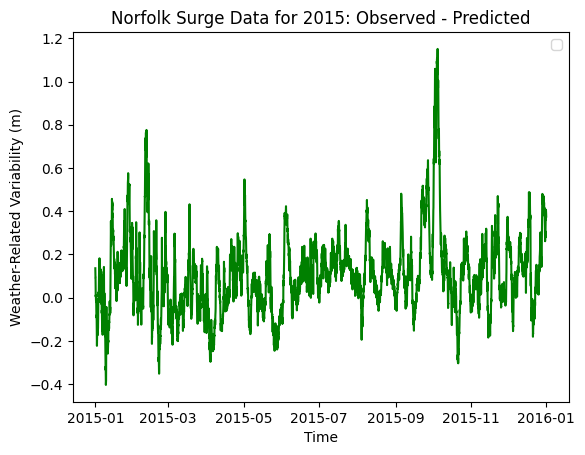

In [17]:
plt.plot(surge.Datetime, surge.Weather, color="green")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Weather-Related Variability (m)")
plt.title("Norfolk Surge Data for 2015: Observed - Predicted")

In [18]:
k = 20
n = len(surge.Weather)
m = n/k
blocks = []
for i in range(n-k+1):
    blocks.append(surge.Weather[i:i+k])
nblocks = len(blocks)

In [19]:
block_samples = []
bootmedians = []
for i in range(1000):
    bootseries = []
    for j in range(int(m)):
        idx = np.random.randint(0, nblocks)
        block = blocks[idx]
        bootseries.append(block)
    bootseries = np.array(bootseries).flatten()
    block_samples.append(bootseries)
    bootmedians.append(np.median(bootseries))
block_samples = np.array(block_samples)
bootmedians = np.array(bootmedians)

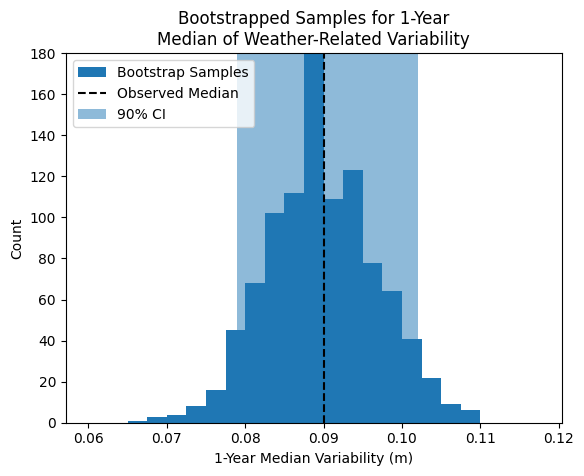

In [20]:
plt.hist(bootmedians, bins=np.arange(0.06, 0.12, 0.0025), label="Bootstrap Samples")
plt.vlines(surge.Weather.median(), 0, 180, "k", linestyles="--", label="Observed Median")
min, max = ci(surge.Weather.median(), bootmedians)
plt.axvspan(min, max, 0, 180, alpha=0.5, label="90% CI")
plt.legend(loc="upper left")
plt.ylim(0, 180)
plt.xlabel("1-Year Median Variability (m)")
plt.ylabel("Count")
plt.title("Bootstrapped Samples for 1-Year\nMedian of Weather-Related Variability")
plt.savefig("images/fig4.png")

In [21]:
print(f"Bias in estimator: {bootmedians.mean() - surge.Weather.median():5.5f}")
print(f"90% CI: ({min:5.5f}, {max:5.5f})")

Bias in estimator: -0.00016
90% CI: (0.07897, 0.10200)


### 2.2

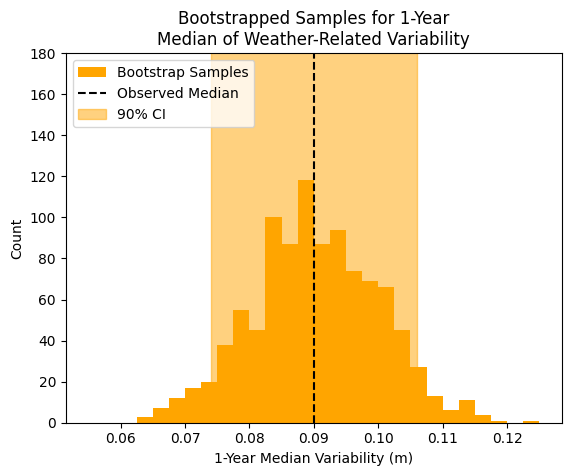

In [22]:
k = 50
n = len(surge.Weather)
m = n/k
blocks = []
for i in range(n-k+1):
    blocks.append(surge.Weather[i:i+k])
nblocks = len(blocks)

block_samples = []
bootmedians = []
for i in range(1000):
    bootseries = []
    for j in range(int(m)):
        idx = np.random.randint(0, nblocks)
        block = blocks[idx]
        bootseries.append(block)
    bootseries = np.array(bootseries).flatten()
    block_samples.append(bootseries)
    bootmedians.append(np.median(bootseries))
block_samples = np.array(block_samples)
bootmedians = np.array(bootmedians)

plt.hist(bootmedians, bins=np.arange(0.055, 0.125, 0.0025), color="orange", label="Bootstrap Samples")
plt.vlines(surge.Weather.median(), 0, 180, "k", linestyles="--", label="Observed Median")
min, max = ci(surge.Weather.median(), bootmedians)
plt.axvspan(min, max, 0, 180, alpha=0.5, label="90% CI", color="orange")
plt.legend(loc="upper left")
plt.ylim(0, 180)
plt.xlabel("1-Year Median Variability (m)")
plt.ylabel("Count")
plt.title("Bootstrapped Samples for 1-Year\nMedian of Weather-Related Variability")
plt.savefig("images/fig5.png")

In [23]:
print(f"Bias in estimator: {bootmedians.mean() - surge.Weather.median():5.5f}")
print(f"90% CI: ({min:5.5f}, {max:5.5f})")

Bias in estimator: 0.00048
90% CI: (0.07400, 0.10600)


# Problem 3
### 3.1

In [48]:
chicago = pd.read_csv("data/chicago.csv")

In [62]:
bad = chicago[chicago.pm10median.isna()]

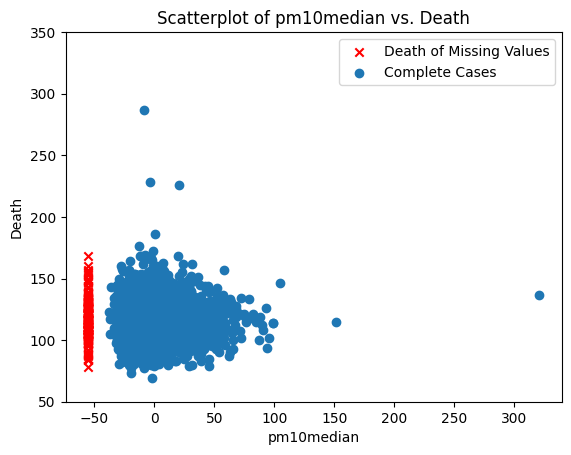

In [76]:
plt.scatter([-55]*len(bad), bad.death, color="r", marker="x", label="Death of Missing Values")
plt.scatter(chicago.pm10median, chicago.death, label="Complete Cases")
plt.ylim(50, 350)
plt.xlabel("pm10median")
plt.ylabel("Death")
plt.title("Scatterplot of pm10median vs. Death")
plt.legend()
plt.savefig("images/fig6.png")

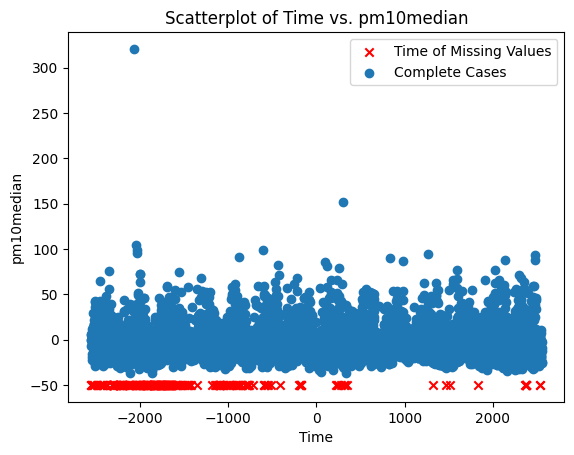

In [77]:
plt.scatter(bad.time, [-50]*len(bad), color="r", marker="x", label="Time of Missing Values")
plt.scatter(chicago.time, chicago.pm10median, label="Complete Cases")
plt.xlabel("Time")
plt.ylabel("pm10median")
plt.title("Scatterplot of Time vs. pm10median")
plt.legend()
plt.savefig("images/fig7")